# Data exploration

### Imports

In [1]:
from config import ExperimentConfig
from dataset import prepare_data
from dataset import build_val_transform
from PIL import Image as PILImage

import sys
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## Testing data preparation

The data pipeline:
1. Loads `train.csv` with (Image, Id) pairs
2. Uses a hybrid split: stratifies classes with enough samples and keeps ultra-rare classes in training to make testing more "fair"
3. Excludes `new_whale` from training (it's not a class — it's the *absence* of a known class)
4. Keeps `new_whale` in validation to track open-set detection performance
5. Builds contiguous class indices for the known whale identities

In [2]:
# These are the splits we will use in the actual analysis
config = ExperimentConfig(
    experiment_name="test_prepare_data",
    description="Just testing preparing data")

data = prepare_data(config)

print(f"\nClass mapping: {data['num_classes']} known whale identities")
print(f"ID → Index examples: {dict(list(data['id_to_idx'].items())[:5])} ...")


Split (seed=42): train=7452 (4250 cls), val=1217 (405 new_whale), test=1181 (405 new_whale)

Class mapping: 4250 known whale identities
ID → Index examples: {'w_0013924': 0, 'w_001ebbc': 1, 'w_002222a': 2, 'w_002b682': 3, 'w_002dc11': 4} ...


### Amount of images per class

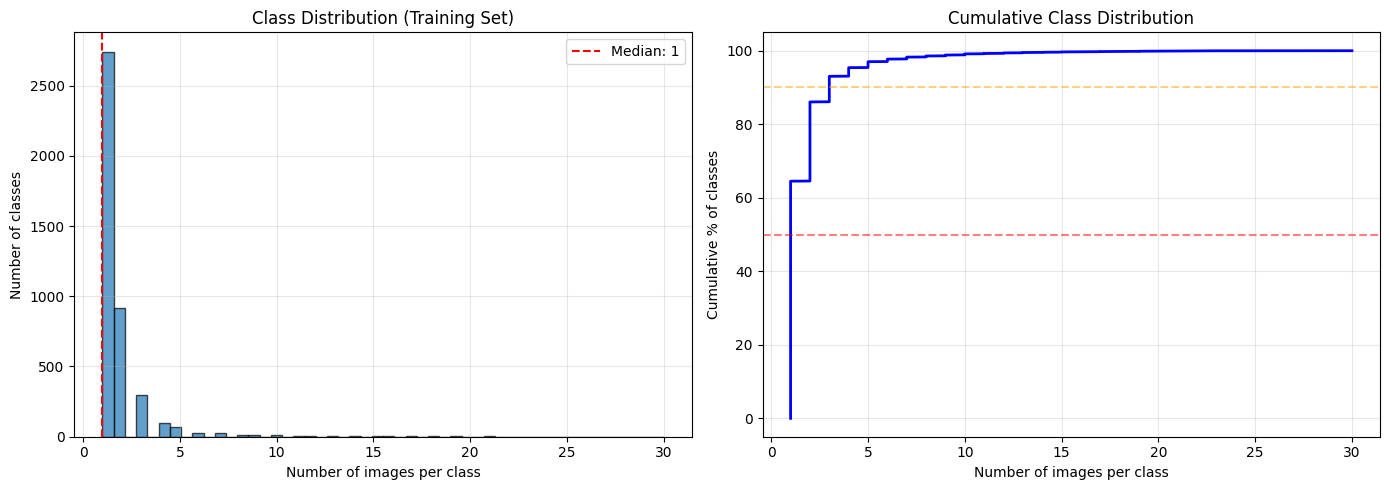

Key statistics:
Total amount of classes:   4250
Classes with 1 image:   2742 (64.5%)
Classes with 2 images: 916 (21.6%)
Classes with 3 images: 296 (7.0%)
Classes with <= 3 images: 3954 (93.0%)


In [3]:
# Class distribution analysis

class_counts = data["class_counts"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of samples per class
ax = axes[0]
ax.hist(class_counts, bins=50, edgecolor="black", alpha=0.7)
ax.set_xlabel("Number of images per class")
ax.set_ylabel("Number of classes")
ax.set_title("Class Distribution (Training Set)")
ax.axvline(x=np.median(class_counts), color="red", linestyle="--",
           label=f"Median: {np.median(class_counts):.0f}")
ax.legend()
ax.grid(True, alpha=0.3)

# Cumulative: what fraction of classes have ≤ N images?
ax = axes[1]
sorted_counts = np.sort(class_counts)
cumulative = np.arange(1, len(sorted_counts) + 1) / len(sorted_counts) * 100
ax.plot(sorted_counts, cumulative, "b-", linewidth=2)
ax.set_xlabel("Number of images per class")
ax.set_ylabel("Cumulative % of classes")
ax.set_title("Cumulative Class Distribution")
ax.axhline(y=50, color="red", linestyle="--", alpha=0.5)
ax.axhline(y=90, color="orange", linestyle="--", alpha=0.5)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('img/class_distribution.png', bbox_inches='tight', dpi=300)
plt.show()

print("Key statistics:")
print(f"Total amount of classes:   {len(class_counts)}")
print(f"Classes with 1 image:   {(class_counts == 1).sum()} ({(class_counts == 1).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with 2 images: {(class_counts == 2).sum()} ({(class_counts == 2).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with 3 images: {(class_counts == 3).sum()} ({(class_counts == 3).sum() / len(class_counts) * 100:.1f}%)")
print(f"Classes with <= 3 images: {(class_counts <= 3).sum()} ({(class_counts <= 3).sum() / len(class_counts) * 100:.1f}%)")



### Sample images

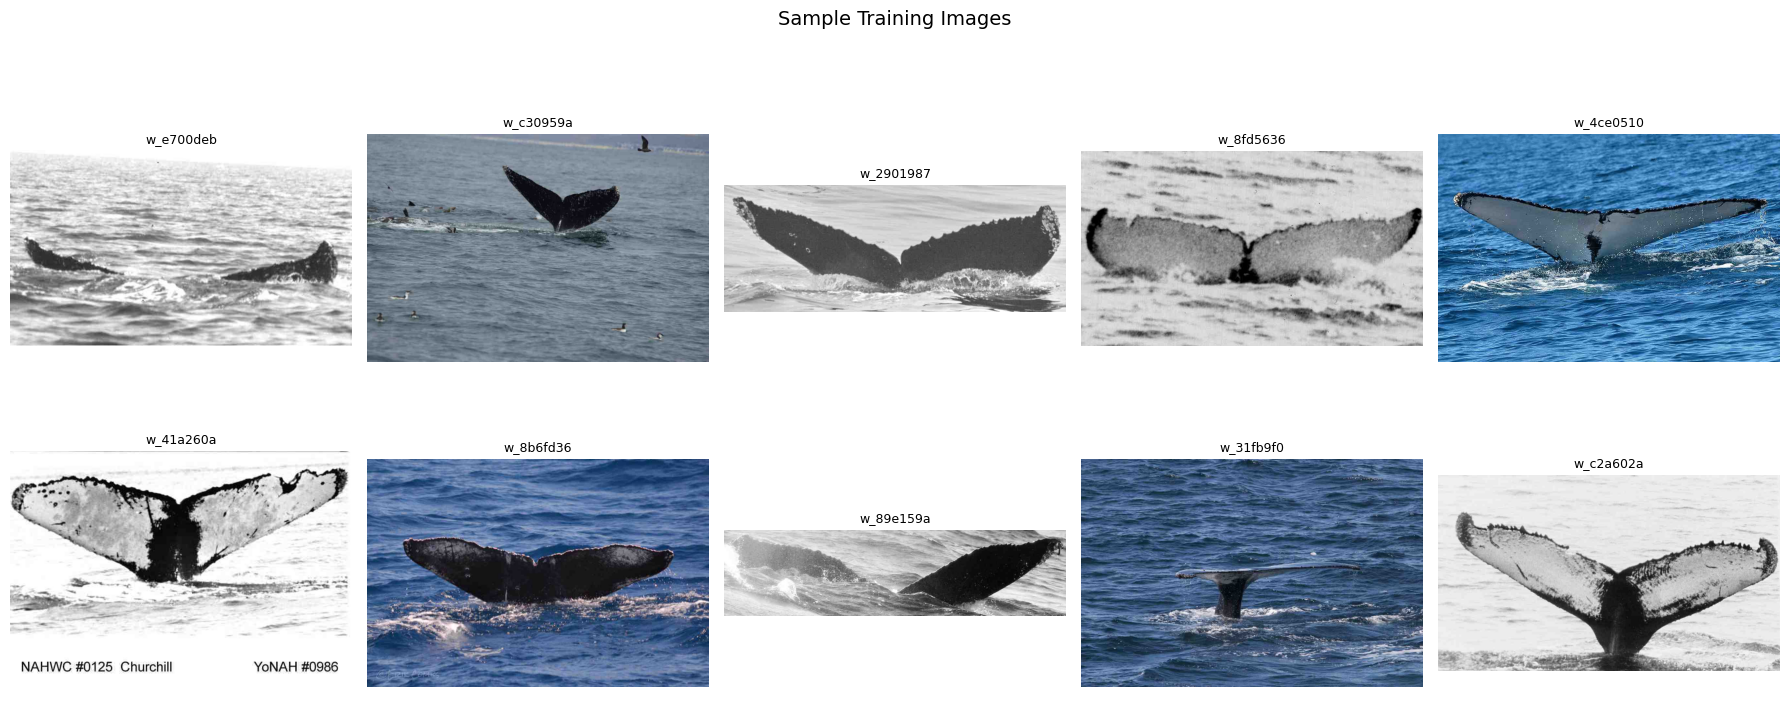

In [4]:
# Show a few training images with their labels
fig, axes = plt.subplots(2, 5, figsize=(18, 8))
sample_df = data["train_df"].sample(10, random_state=42)
transform = build_val_transform(config)

for i, (_, row) in enumerate(sample_df.iterrows()):
    ax = axes[i // 5, i % 5]
    img_path = os.path.join(config.data_dir, "train", row["Image"])
    try:
        img = PILImage.open(img_path).convert("RGB")
        ax.imshow(img)
        ax.set_title(row["Id"][:15], fontsize=9)
    except Exception as e:
        ax.text(0.5, 0.5, f"Load error: {e}", ha="center")
    ax.axis("off")

plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


### Test DataLoaders

Augmentation philosophy for whale flukes:
- **YES**: Mild rotation, brightness/contrast jitter, slight crop variation, gentle blur
- **NO**: Horizontal flip (left/right notch patterns are identity-specific),
  random erasing (could delete the exact notch that identifies the whale),
  heavy geometric distortion (changes trailing-edge shape)


Train batches: 621 (micro-batch=12, effective=24)
Val batches:   51


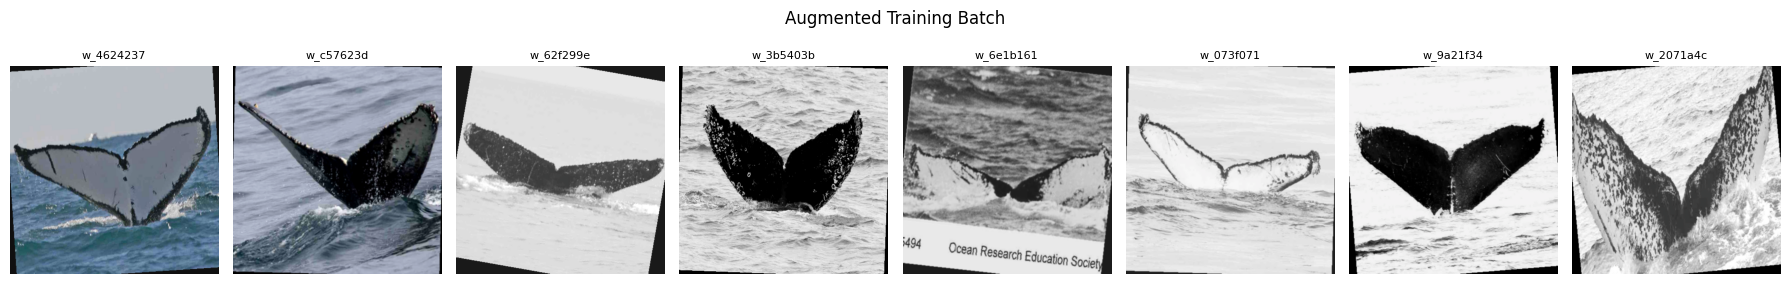

In [5]:
from dataset import build_dataloaders

train_loader, val_loader = build_dataloaders(config, data)

print(f"Train batches: {len(train_loader)} (micro-batch={config.batch_size}, "
      f"effective={config.batch_size * config.accumulation_steps})")
print(f"Val batches:   {len(val_loader)}")

# Show a batch with augmentation applied
images, labels = next(iter(train_loader))
fig, axes = plt.subplots(1, min(8, len(images)), figsize=(18, 3))

# Denormalize for display
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

for i, ax in enumerate(axes):
    img = images[i].cpu() * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1).numpy()
    ax.imshow(img)
    label = labels[i].item()
    id_str = data["idx_to_id"].get(label, "new_whale") if label >= 0 else "new_whale"
    ax.set_title(f"{id_str[:12]}", fontsize=8)
    ax.axis("off")

plt.suptitle("Augmented Training Batch", fontsize=12)
plt.tight_layout()
plt.show()
